# Examples in the paper

Chu, Junyan. Free resolution of the logarithmic derivation modules of close to free arrangements. J Algebr Comb 61, 26 (2025).
  https://doi.org/10.1007/s10801-025-01394-7.

In [1]:
#%display latex
from IPython.display import Math, display
from matplotlib import pyplot as plt
import sage.misc.latex as sage_latex
import sys,itertools
from tqdm.auto import tqdm as tqdm

sys.path.insert(0, './src')
from hyperplane_arrangements import *

# replace the default show function with one that works better in VSCode
import shutil, sys
try:
    original_show = show
except NameError:
    from IPython.display import Markdown, display
    display(Markdown(
        "## ⚠ Wrong Kernel\n\n"
        + "\n".join(f"- {e}" for e in _err)
        + "\n\n**This notebook must be run with the SageMath kernel, not a plain Python kernel.**\n\n"
        "In JupyterLab: *Kernel → Change Kernel → SageMath*\n\n"
        "In VS Code: click the kernel name in the top-right corner and select *SageMath*."
    ))
    raise SystemExit("Switch to the SageMath kernel and re-run.")
else:
    print(f"OK: SageMath kernel (Python {sys.version.split()[0]})")

def vscode_show(*args, **kwargs):
    for expr in args:
        try:
            if hasattr(expr, '_latex_'):
                display(Math(expr._latex_()))
            else:
                display(Math(sage_latex.latex(expr)))
        except Exception as e:
            print(f"LaTeX rendering failed: {e}")
            original_show(expr, **kwargs)
show = vscode_show
print(sage.version.banner)


OK: SageMath kernel (Python 3.12.12)
SageMath version 10.7, Release Date: 2025-08-09


### dimension 3

10 Cached version of <function HyperplaneArrangement.degs at 0x172769a80>
B: 0 [1, 3, 6, 6]
B: 1 [1, 3, 6, 6]
B: 2 [1, 2, 6]
B: 3 [1, 3, 5]
B: 4 [1, 3, 5]
B: 5 [1, 3, 5]
B: 6 [1, 3, 5]
B: 7 [1, 3, 6, 6]
B: 8 [1, 2, 6]
B: 9 [1, 2, 6]


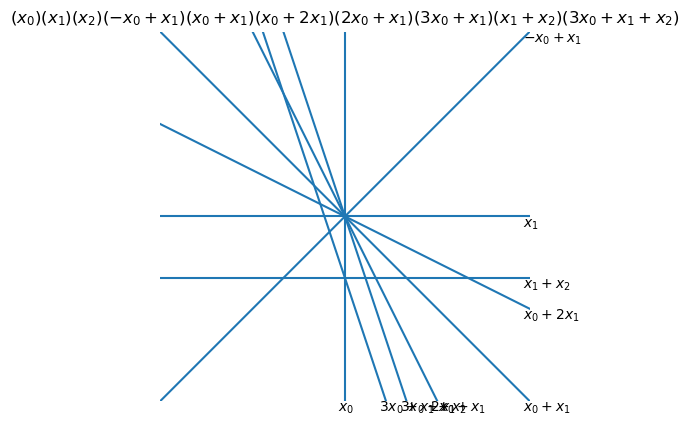

In [4]:
#A=HyperPlaneArr([[0,0,1],[1,0,0],[0,1,0],[1 ,0, 1],[1 ,1, 0],[1,-1,0],[0 ,1, 1],[-1 ,0, 1],[1 ,1, 1],[1 ,-2, 1],[1,2,1]])
#A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[1 ,1, 0],[0 ,1, 1],[0 ,1, -1],[1 ,0, 1],[1,-1,0],[1 ,1, 1],[1,1,-2],[1 ,1, 2]])
A=HyperPlaneArr([[1,0,0],[0,1,0],[0,0,1],[-1 ,1, 0],[1,1,0],[1,2,0],[2,1,0],[3,1,0],[0,1,1],[3,1,1]])
A.plot(xlim=(-3,3),ylim=(-3,3))
print(A.num_planes,A.degs)
SPOGs = []
for i in range(A.num_planes):
    B=A.deletion([i])
    print('B:',i,B.degs())
    if B.is_spog():
        SPOGs.append(i)

In [5]:
LL = list(itertools.combinations(range(A.num_planes),2))
results = {}
for i,j in tqdm(LL):
    B=A.deletion([i,j])
    results[(i,j)]=B.degs()
    if B.is_spog() and (i in SPOGs) and (j in SPOGs):
        (c,_),RHS = B.level_coeff()
        print(f"SPOG:",(i,j),B.degs(), f"level coeff: {c}")
    elif B.is_free:
        print('free: ',(i,j),B.degs())
    else:
        st = f"pd={len(B.free_resolution())-1}"
        print(st,(i,j),B.degs())


  0%|          | 0/45 [00:00<?, ?it/s]

SPOG: (0, 1) [1, 3, 5, 6] level coeff: -x1 - x2
pd=1 (0, 2) [1, 2, 6, 6]
pd=1 (0, 3) [1, 3, 5, 5]
pd=1 (0, 4) [1, 3, 5, 5]
pd=1 (0, 5) [1, 3, 5, 5]
pd=1 (0, 6) [1, 3, 5, 5]
SPOG: (0, 7) [1, 3, 5, 6] level coeff: -3*x0 - x1 - x2
free:  (0, 8) [1, 2, 5]
free:  (0, 9) [1, 2, 5]
free:  (1, 2) [1, 2, 5]
pd=1 (1, 3) [1, 3, 5, 5]
pd=1 (1, 4) [1, 3, 5, 5]
pd=1 (1, 5) [1, 3, 5, 5]
pd=1 (1, 6) [1, 3, 5, 5]
SPOG: (1, 7) [1, 3, 5, 6] level coeff: 216*x2
free:  (1, 8) [1, 2, 5]
pd=1 (1, 9) [1, 2, 6, 6]
free:  (2, 3) [1, 2, 5]
free:  (2, 4) [1, 2, 5]
free:  (2, 5) [1, 2, 5]
free:  (2, 6) [1, 2, 5]
free:  (2, 7) [1, 2, 5]
free:  (2, 8) [1, 1, 6]
free:  (2, 9) [1, 1, 6]
free:  (3, 4) [1, 3, 4]
free:  (3, 5) [1, 3, 4]
free:  (3, 6) [1, 3, 4]
pd=1 (3, 7) [1, 3, 5, 5]
free:  (3, 8) [1, 2, 5]
free:  (3, 9) [1, 2, 5]
free:  (4, 5) [1, 3, 4]
free:  (4, 6) [1, 3, 4]
pd=1 (4, 7) [1, 3, 5, 5]
free:  (4, 8) [1, 2, 5]
free:  (4, 9) [1, 2, 5]
free:  (5, 6) [1, 3, 4]
pd=1 (5, 7) [1, 3, 5, 5]
free:  (5, 8) [1, 2, 5

In [6]:
for i in range(A.num_planes):
    print(f"\nLooking at {i}-th plane")
    B=A.deletion([i])
    if B.is_free:
        print(f"del {i} is free",B.degs())
    else:
        C=A.restriction(i)
        print(f"Res to {i} free?: {C.is_free}, {C.degs()}")
        for j in range(i+1,A.num_planes):
            B=A.deletion([i,j])
            results[(i,j)]=B.degs()
            if B.is_spog():
                print('SPOG:',(i,j),B.degs())
            elif B.is_free:
                print('free: ',(i,j),B.degs())
            else:
                st = f"pd={len(B.free_resolution())-1}"
                print(st,(i,j),B.degs())



Looking at 0-th plane
Res to 0 free?: True, [1, 2]
SPOG: (0, 1) [1, 3, 5, 6]
SPOG: (0, 2) [1, 2, 6, 6]
SPOG: (0, 3) [1, 3, 5, 5]
SPOG: (0, 4) [1, 3, 5, 5]
SPOG: (0, 5) [1, 3, 5, 5]
SPOG: (0, 6) [1, 3, 5, 5]
SPOG: (0, 7) [1, 3, 5, 6]
free:  (0, 8) [1, 2, 5]
free:  (0, 9) [1, 2, 5]

Looking at 1-th plane
Res to 1 free?: True, [1, 2]
free:  (1, 2) [1, 2, 5]
SPOG: (1, 3) [1, 3, 5, 5]
SPOG: (1, 4) [1, 3, 5, 5]
SPOG: (1, 5) [1, 3, 5, 5]
SPOG: (1, 6) [1, 3, 5, 5]
SPOG: (1, 7) [1, 3, 5, 6]
free:  (1, 8) [1, 2, 5]
SPOG: (1, 9) [1, 2, 6, 6]

Looking at 2-th plane
del 2 is free [1, 2, 6]

Looking at 3-th plane
del 3 is free [1, 3, 5]

Looking at 4-th plane
del 4 is free [1, 3, 5]

Looking at 5-th plane
del 5 is free [1, 3, 5]

Looking at 6-th plane
del 6 is free [1, 3, 5]

Looking at 7-th plane
Res to 7 free?: True, [1, 2]
SPOG: (7, 8) [1, 2, 6, 6]
free:  (7, 9) [1, 2, 5]

Looking at 8-th plane
del 8 is free [1, 2, 6]

Looking at 9-th plane
del 9 is free [1, 2, 6]


### dimension 4

In [7]:
mat=[[ 1,  0,  0,  0],
[ 0,  1,  0,  0],
[ 0,  0,  1,  0],
[-1,  1,  0,  0],
[-1,  0,  1,  0],
[ 0, -1,  1,  0],
[ 0,  0,  0,  1],
[ 0,  1, -1,  1],
[-1,  1, -1,  1],
[ 0,  0, -1,  1]]
A=HyperPlaneArr(mat)
print(f"Num of planes: {A.num_planes}, Deg. Seq. {A.degs()}")
A.free_resolution()


Num of planes: 10, Deg. Seq. [1, 3, 3, 3]


S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-3)⊕S(-3) <-- 0

In [8]:
# example for (d_1,...,d_l,c_1,c_2) is a proper subseq. of the degree seq.
B=A.deletion([2,9])
print(f"Num of planes: {B.num_planes}, Deg. Seq. {B.degs()}")
B.free_resolution()


Num of planes: 8, Deg. Seq. [1, 3, 3, 3, 3, 3, 3]


S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3) <-- S(-4)⊕S(-4)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0

In [9]:
# list all minus-two
## restriction to both 0 and 2 are free, but minus {0,2} has more generators than dim+2
results = {}
for i in range(A.num_planes):
    print(f"\nLooking at {i}-th plane")
    B=A.deletion([i])
    print(f"del {i} degrees: {B.degs()}, is SPOG: {B.is_spog()}")
    C=A.restriction(i)
    print(f"Res to {i} free?: {C.is_free}, {C.degs()}, is SPOG: {C.is_spog()}")
    if B.is_free:
        print(f"del {i} is free")
    else:
        for j in range(i+1,A.num_planes):
            B=A.deletion([i,j])
            results[(i,j)]=B.degs()
            if B.is_spog():
                print('SPOG: del',(i,j),B.degs())
            elif B.is_free:
                print('free: del',(i,j),B.degs())
            else:
                st = f"pd={len(B.free_resolution())-1}"
                print(st," del",(i,j),B.degs())


Looking at 0-th plane
del 0 degrees: [1, 3, 3, 3, 3], is SPOG: [1, 3, 3, 3, 3]
Res to 0 free?: True, [1, 2, 3], is SPOG: False
SPOG: del (0, 1) [1, 2, 3, 3, 3]
pd=2  del (0, 2) [1, 3, 3, 3, 3, 3, 3]
SPOG: del (0, 3) [1, 2, 3, 3, 3]
free: del (0, 4) [1, 2, 2, 3]
pd=1  del (0, 5) [1, 3, 3, 3, 3, 3]
SPOG: del (0, 6) [1, 2, 3, 3, 3]
pd=2  del (0, 7) [1, 3, 3, 3, 3, 3, 3]
free: del (0, 8) [1, 2, 2, 3]
pd=1  del (0, 9) [1, 3, 3, 3, 3, 3]

Looking at 1-th plane
del 1 degrees: [1, 3, 3, 3, 3], is SPOG: [1, 3, 3, 3, 3]
Res to 1 free?: False, [1, 3, 3, 3], is SPOG: [1, 3, 3, 3]
SPOG: del (1, 2) [1, 2, 3, 3, 3]
SPOG: del (1, 3) [1, 2, 3, 3, 3]
SPOG: del (1, 4) [1, 2, 3, 3, 3]
SPOG: del (1, 5) [1, 2, 3, 3, 3]
SPOG: del (1, 6) [1, 2, 3, 3, 3]
SPOG: del (1, 7) [1, 2, 3, 3, 3]
SPOG: del (1, 8) [1, 2, 3, 3, 3]
SPOG: del (1, 9) [1, 2, 3, 3, 3]

Looking at 2-th plane
del 2 degrees: [1, 3, 3, 3, 3], is SPOG: [1, 3, 3, 3, 3]
Res to 2 free?: True, [1, 2, 3], is SPOG: False
pd=1  del (2, 3) [1, 3, 3, 3, 3,

In [10]:
#another example for (d_1,...,d_l,c_1,c_2) is a proper subseq. of the degree seq.
mat=[[1,0,0,0],[1,1,0,0],[1,0,1,0],[1,0,0,1],[1,-1,0,0],[1,0,-1,0],[1,0,0,-1],[0,1,-1,0],[0,0,1,-1],[0,1,0,1]]
A=HyperPlaneArr(mat)
print(f"A: Num of planes: {A.num_planes}, Deg. Seq. {A.degs()}")
print(A.free_resolution(),"\n")
B=A.deletion([1,2])
print(f"B: Num of planes: {B.num_planes}, Deg. Seq. {B.degs()}")
B.free_resolution()


A: Num of planes: 10, Deg. Seq. [1, 3, 3, 3]
S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-3)⊕S(-3) <-- 0 

B: Num of planes: 8, Deg. Seq. [1, 3, 3, 3, 3, 3, 3]


S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3) <-- S(-4)⊕S(-4)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0

In [11]:
B=A.deletion([1,2])
print(f"B: Num of planes: {B.num_planes}, Deg. Seq. {B.degs()}")
B.free_resolution()


B: Num of planes: 8, Deg. Seq. [1, 3, 3, 3, 3, 3, 3]


S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3)⊕S(-3) <-- S(-4)⊕S(-4)⊕S(-4)⊕S(-4) <-- S(-5) <-- 0

In [12]:
mat=coord_vec(4)+[[1 ,-1,0, 0],[1,0 ,-1, 0],[1,0,0,-1],[0 ,1, -1,0],[0,1 ,0, -1],[0,0,1,-1],[0,1 ,-1, 1],[1,-1,1,-1]]
A=HyperPlaneArr(mat)
print(f"A: Num of planes: {A.num_planes}, Deg. Seq. {A.degs()}")
print(A.free_resolution(),"\n")
B=A.deletion([0,1])
print(f"B: Num of planes: {B.num_planes}, Deg. Seq. {B.degs()}")
print(B.free_resolution(),"\n")
B1=A.deletion([0,7])
print(f"B1: Num of planes: {B1.num_planes}, Deg. Seq. {B1.degs()}")
print(B1.free_resolution(),"\n")
B2=A.deletion([1,9])
print(f"B2: Num of planes: {B2.num_planes}, Deg. Seq. {B2.degs()}")
print(B2.free_resolution())


A: Num of planes: 12, Deg. Seq. [1, 3, 4, 4]
S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4) <-- 0 

B: Num of planes: 10, Deg. Seq. [1, 3, 3, 4, 4]
S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4)⊕S(-3) <-- S(-5) <-- 0 

B1: Num of planes: 10, Deg. Seq. [1, 3, 4, 4, 4, 5]
S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4)⊕S(-5)⊕S(-4) <-- S(-5)⊕S(-6) <-- 0 

B2: Num of planes: 10, Deg. Seq. [1, 3, 4, 4, 4, 4]
S(0)⊕S(0)⊕S(0)⊕S(0) <-- S(-1)⊕S(-3)⊕S(-4)⊕S(-4)⊕S(-4)⊕S(-4) <-- S(-5)⊕S(-5) <-- 0


In [13]:
# list all minus-two
## note: when multi-restriction is non-free, pd<2.
results = {}
for i in range(A.num_planes):
    print(f"\nLooking at {i}-th plane")
    B=A.deletion([i])
    print(f"del {i} degrees: ",B.degs(), f"is SPOG: {B.is_spog()}")
    C=A.restriction(i)
    print(f"Res to {i} free?: {C.is_free}, {C.degs()}, is SPOG: {C.is_spog()},")
    if B.is_free:
        print(f"del {i} is free")
    else:
        for j in range(i+1,A.num_planes):
            B=A.deletion([i,j])
            results[(i,j)]=B.degs()
            prt = ""
            if B.is_spog():
                prt += f'SPOG: del {(i,j)}\n\tdegs {str(B.degs()):<25}'
            elif B.is_free:
                prt += f'free: del {(i,j)}\n\tdegs {str(B.degs()):<25}'
            else:
                prt += f'pd={len(B.free_resolution())-1}: del {(i,j)}\n\tdegs {str(B.degs()):<25}'

            prt += f'localisation {str(A.localisation([i,j]).degs()):<25}\n'
            Aij = A.deletion([i]).restriction(j-1)
            Aji = A.deletion([j]).restriction(i)
            prt += f'\trestriction A_i^j {str(Aij.degs()):<25}'
            prt += f'A_j^i {str(Aji.degs()):<25}\n'
            prt += f'\tmulti-restriction A_i^j {str(degseq(Aij.compute_multi_minimal_generators())):<25}'
            prt += f'A_j^i {str(degseq(Aji.compute_multi_minimal_generators())):<25}'
            print(prt)


Looking at 0-th plane
del 0 degrees:  [1, 3, 4, 4, 4] is SPOG: [1, 3, 4, 4, 4]
Res to 0 free?: True, [1, 3, 3], is SPOG: False,
SPOG: del (0, 1)
	degs [1, 3, 3, 4, 4]          localisation [0, 0, 1, 2]             
	restriction A_i^j [1, 3, 3]                A_j^i [1, 3, 3]                
	multi-restriction A_i^j [3, 4, 4, 4]             A_j^i [3, 4, 4, 4]             
free: del (0, 2)
	degs [1, 3, 3, 3]             localisation [0, 0, 1, 2]             
	restriction A_i^j [1, 3, 4]                A_j^i [1, 3, 3]                
	multi-restriction A_i^j [3, 3, 4]                A_j^i [3, 3, 4]                
SPOG: del (0, 3)
	degs [1, 3, 3, 4, 4]          localisation [0, 0, 1, 2]             
	restriction A_i^j [1, 3, 3]                A_j^i [1, 3, 3]                
	multi-restriction A_i^j [3, 4, 4, 4]             A_j^i [3, 4, 4, 4]             
SPOG: del (0, 4)
	degs [1, 3, 3, 4, 4]          localisation [0, 0, 1, 2]             
	restriction A_i^j [1, 3, 3]                A_j^i

In [14]:
# list all minus-two
## note: when multi-restriction is non-free, pd<2.
#mat=coord_vec(4)+[[1 ,-1,0, 0],[1,0 ,-1, 0],[1,0,0,-1],[0 ,1, -1,0],[0,1 ,0, -1],[0,0,1,-1],[0,1 ,-1, 1],[1,-1,1,-1]]
mat=[[1,0,0,0],[1,1,0,0],[1,0,1,0],[1,0,0,1],[1,-1,0,0],[1,0,-1,0],[1,0,0,-1],[0,1,-1,0],[0,0,1,-1],[0,1,0,1]]

A=HyperPlaneArr(mat)
results = {}
for i in range(A.num_planes):
    print(f"\nLooking at {i}-th plane")
    B=A.deletion([i])
    print(f"del {i} degrees: ",B.degs(), f"is SPOG: {B.is_spog()}")
    C=A.restriction(i)
    print(f"Res to {i} free?: {C.is_free}, {C.degs()}, is SPOG: {C.is_spog()},")
    if B.is_free:
        print(f"del {i} is free")
    else:
        for j in range(i+1,A.num_planes):
            B=A.deletion([i,j])
            results[(i,j)]=B.degs()
            prt = ""
            if B.is_spog():
                #LHS,RHS = B.level_coeff()
                prt += f'SPOG: del {(i,j)}\n\tdegs {str(B.degs()):<25}' #, f"level coeff: {LHS[0]}")
            elif B.is_free:
                prt += f'free: del {(i,j)}\n\tdegs {str(B.degs()):<25}'
            else:
                prt += f'pd={len(B.free_resolution())-1}: del {(i,j)}\n\tdegs {str(B.degs()):<25}'
            prt += f'localisation {str(A.localisation([i,j]).degs()):<25}\n'
            Aij = A.deletion([i]).restriction(j-1)
            Aji = A.deletion([j]).restriction(i)
            prt += f'\trestriction A_i^j {str(Aij.degs()):<25}'
            prt += f'A_j^i {str(Aji.degs()):<25}\n'
            prt += f'\tmulti-restriction A_i^j {str(degseq(Aij.compute_multi_minimal_generators())):<25}'
            prt += f'A_j^i {str(degseq(Aji.compute_multi_minimal_generators())):<25}'
            print(prt)


Looking at 0-th plane
del 0 degrees:  [1, 3, 3, 3, 3] is SPOG: [1, 3, 3, 3, 3]
Res to 0 free?: False, [1, 3, 3, 3], is SPOG: [1, 3, 3, 3],
SPOG: del (0, 1)
	degs [1, 2, 3, 3, 3]          localisation [0, 0, 1, 2]             
	restriction A_i^j [1, 2, 3]                A_j^i [1, 3, 3, 3]             
	multi-restriction A_i^j [3, 3, 3, 3]             A_j^i [3, 3, 3, 3]             
SPOG: del (0, 2)
	degs [1, 2, 3, 3, 3]          localisation [0, 0, 1, 2]             
	restriction A_i^j [1, 2, 3]                A_j^i [1, 3, 3, 3]             
	multi-restriction A_i^j [3, 3, 3, 3]             A_j^i [3, 3, 3, 3]             
SPOG: del (0, 3)
	degs [1, 2, 3, 3, 3]          localisation [0, 0, 1, 2]             
	restriction A_i^j [1, 2, 3]                A_j^i [1, 3, 3, 3]             
	multi-restriction A_i^j [3, 3, 3, 3]             A_j^i [3, 3, 3, 3]             
SPOG: del (0, 4)
	degs [1, 2, 3, 3, 3]          localisation [0, 0, 1, 2]             
	restriction A_i^j [1, 2, 3]          